# Load ECGEncoder from a checkpoint

Build the encoder with the same preset you used for training (`final_preset()` vs `dev_preset()` in `src/configs/presets.py`). A **final** checkpoint (D=768, 12 layers) will not load into a **dev** encoder (D=384, 6 layers). Adjust `CHECKPOINT` if your file lives elsewhere.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import torch

# Project root (parent of `src/`)
ROOT = Path.cwd()
if not (ROOT / "src" / "encoder.py").is_file():
    ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.configs import EncoderConfig, TokenizerConfig
from src.encoder import ECGEncoder
from src.tokenizer import ECGTokenizer
from src.configs.presets import dev_preset, final_preset

CHECKPOINT = ROOT / "checkpoints/dev_preset_final/checkpoint_epoch_9.pt"

# Must match the architecture that produced CHECKPOINT (here: final = 12L, D=768).
tok_cfg, enc_cfg, _ = dev_preset()

enc_cfg.use_flash = True

tokenizer = ECGTokenizer(tok_cfg)
encoder = ECGEncoder(enc_cfg, tokenizer)
encoder.eval()

ECGEncoder(
  (tokenizer): ECGTokenizer(
    (proj): Linear(in_features=50, out_features=384, bias=True)
  )
  (blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): DropPath()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)

In [2]:
def _unwrap_checkpoint(obj: object) -> dict[str, torch.Tensor]:
    """Accept raw state_dict or common training wrappers."""
    if isinstance(obj, dict):
        for key in ("context_encoder", "student", "encoder", "model", "state_dict", "net"):
            inner = obj.get(key)
            if isinstance(inner, dict) and inner and isinstance(next(iter(inner.values())), torch.Tensor):
                return inner  # type: ignore[return-value]
        if obj and isinstance(next(iter(obj.values())), torch.Tensor):
            return obj  # type: ignore[return-value]
    raise TypeError(f"Unexpected checkpoint type: {type(obj)}")


def _strip_prefix(sd: dict[str, torch.Tensor], prefixes: tuple[str, ...]) -> dict[str, torch.Tensor]:
    out: dict[str, torch.Tensor] = {}
    for k, v in sd.items():
        nk = k
        for p in prefixes:
            if nk.startswith(p):
                nk = nk[len(p) :]
                break
        out[nk] = v
    return out


def load_encoder_weights(module: ECGEncoder, path: Path, *, device: str | torch.device = "cpu") -> None:
    # Use weights_only=False if your file stores non-tensor metadata alongside tensors.
    blob = torch.load(path, map_location=device, weights_only=False)
    sd = _unwrap_checkpoint(blob)
    mod_keys = set(module.state_dict().keys())
    sd_keys = set(sd.keys())
    # If no overlap, unwrap a common submodule prefix (JEPA context / student encoder).
    if not mod_keys & sd_keys:
        for prefix in (
            "context_encoder.",
            "module.context_encoder.",
            "student.",
            "encoder.",
        ):
            if any(k.startswith(prefix) for k in sd_keys):
                sd = _strip_prefix(sd, (prefix,))
                break
    module.load_state_dict(sd, strict=True)


if not CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT}. Place checkpoint_best.pt at the repo root or set CHECKPOINT."
    )

load_encoder_weights(encoder, CHECKPOINT)
print("Loaded weights from", CHECKPOINT)

Loaded weights from /home/aimakeradmin/shady/TS-JEPA/checkpoints/dev_preset_final/checkpoint_epoch_9.pt


In [3]:
# Smoke test: 12 leads, T = num_patches * patch_size = 2500 @ 50 samples/patch
bs, c, t = 2, enc_cfg.num_leads, enc_cfg.num_patches * enc_cfg.patch_size
signal = torch.randn(bs, c, t)
patches = encoder.tokenizer.patchify(signal)
with torch.no_grad() and torch.amp.autocast('cuda', enabled=enc_cfg.use_flash):
    encoder.to('cuda')
    z = encoder.forward_all(patches.to('cuda'))
print("forward_all out:", z.shape)  # (bs, C*N, D)

forward_all out: torch.Size([2, 400, 384])


In [4]:
from src.data.ptbxl_dataset import PTBXLDataset

# Toggle between datasets for A/B comparisons.
PTBXL_DATA_DIR = ROOT / "data/ptbxl_500hz_2500_raw"
# PTBXL_DATA_DIR = ROOT / "data/ptbxl_500hz_2500_norm"
# PTBXL_DATA_DIR = ROOT / "data/ptbxl"  # legacy 12x1000 arrays

testset = PTBXLDataset(PTBXL_DATA_DIR, split="test", return_labels=True)
print("PTBXL_DATA_DIR:", PTBXL_DATA_DIR)
print("Dataset length:", len(testset))
x, y = testset[500]
print("Sample x shape:", x.shape)
print("Sample y:", y)

PTBXL_DATA_DIR: /home/aimakeradmin/shady/TS-JEPA/data/ptbxl_500hz_2500_raw
Dataset length: 2163
Sample x shape: torch.Size([12, 2500])
Sample y: tensor([0., 0., 1., 0., 0.])


In [5]:
trainset = PTBXLDataset(PTBXL_DATA_DIR, split="train", return_labels=True)
print("Dataset length:", len(trainset))
x, y = trainset[500]
print("Sample x shape:", x.shape)
print("Sample y:", y)

Dataset length: 17111
Sample x shape: torch.Size([12, 2500])
Sample y: tensor([1., 0., 0., 0., 1.])


# Linear Probing

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
from torch import nn

# JEPA paper lead subset: I, II, V1-V6 (drop III/aVR/aVL/aVF).
KEEP_LEAD_IDXS = torch.tensor([0, 1, 6, 7, 8, 9, 10, 11], dtype=torch.long)
TARGET_T = enc_cfg.num_patches * enc_cfg.patch_size


def prepare_signal_for_encoder(x: torch.Tensor) -> torch.Tensor:
    if x.shape[-1] != TARGET_T:
        raise ValueError(
            f"Expected input length {TARGET_T} from PTBXL_DATA_DIR, got {x.shape[-1]}"
        )
    idx = KEEP_LEAD_IDXS.to(device=x.device)
    return x.index_select(dim=1, index=idx)


class Classifier(nn.Module):
    def __init__(self, encoder: ECGEncoder, num_classes: int):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(enc_cfg.embed_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            z = self.encoder.forward_all(x)
        # Simple global average pooling + linear classifier.
        z = z.mean(dim=1)
        return self.classifier(z)

In [8]:
from torch.utils.data import DataLoader, Subset

classifier = Classifier(encoder, num_classes=5)  # PTB-XL has 5 diagnostic classes
classifier.to(device)
tokenizer.to(device)

# Explicitly freeze encoder params for linear probing.
for p in classifier.encoder.parameters():
    p.requires_grad_(False)
classifier.encoder.eval()

def estimate_pos_weight(dataset, num_classes: int, batch_size: int = 512) -> torch.Tensor:
    pos_counts = torch.zeros(num_classes, dtype=torch.float64)
    total = 0
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for _, y in loader:
        y = y.to(torch.float64)
        pos_counts += y.sum(dim=0)
        total += y.shape[0]

    neg_counts = total - pos_counts
    return (neg_counts / pos_counts.clamp_min(1.0)).to(torch.float32)

# Match the tuning subset used below to keep weighting consistent with training data.
weight_set = trainset
pos_weight = estimate_pos_weight(weight_set, num_classes=5).to(device)
print("pos_weight:", pos_weight)

loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(classifier.classifier.parameters(), lr=6e-3)

pos_weight: tensor([3.3740, 7.0674, 2.8986, 1.2494, 3.0808], device='cuda:0')


In [9]:
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, Subset
tuning_set = Subset(trainset, range(6000))  # Use a small subset for tuning
train_loader = DataLoader(trainset, batch_size=512, shuffle=True)
tuning_loader = DataLoader(tuning_set, batch_size=512, shuffle=True)
test_loader = DataLoader(testset, batch_size=512, shuffle=False)

def epoch():
    classifier.classifier.train()
    classifier.encoder.eval()  # Freeze encoder
    running_loss = 0.0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=enc_cfg.use_flash):
            x = prepare_signal_for_encoder(x)
            x = tokenizer.patchify(x)
            logits = classifier(x)
        l = loss(logits, y)
        
        l.backward()
        optimizer.step()
        
        running_loss += l.item()
    print("loss:", running_loss / len(train_loader))
    return running_loss / len(train_loader)
        

In [10]:
[epoch() for _ in range(10)]

loss: 0.8389312800239114
loss: 0.7865234034902909
loss: 0.7741322657641243
loss: 0.7656123743337744
loss: 0.7595474036300883
loss: 0.7542077758732963
loss: 0.7495489698999068
loss: 0.7467093450181624
loss: 0.7429452608613407
loss: 0.7434377442387974


[0.8389312800239114,
 0.7865234034902909,
 0.7741322657641243,
 0.7656123743337744,
 0.7595474036300883,
 0.7542077758732963,
 0.7495489698999068,
 0.7467093450181624,
 0.7429452608613407,
 0.7434377442387974]

In [11]:
def evaluate():
    classifier.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device).int()
            with torch.amp.autocast('cuda', enabled=enc_cfg.use_flash):
                x = prepare_signal_for_encoder(x)
                x = tokenizer.patchify(x)
                logits = classifier(x)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    import numpy as np
    from sklearn.metrics import average_precision_score, classification_report, roc_auc_score

    all_probs = np.asarray(all_probs)
    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    print(classification_report(all_labels, all_preds, zero_division=0))
    try:
        macro_auroc = roc_auc_score(all_labels, all_probs, average="macro")
    except ValueError:
        macro_auroc = float("nan")
    try:
        macro_auprc = average_precision_score(all_labels, all_probs, average="macro")
    except ValueError:
        macro_auprc = float("nan")

    print(f"Macro AUROC: {macro_auroc:.4f}")
    print(f"Macro AUPRC: {macro_auprc:.4f}")

In [12]:
evaluate()

              precision    recall  f1-score   support

           0       0.47      0.69      0.56       498
           1       0.30      0.81      0.44       263
           2       0.48      0.57      0.52       553
           3       0.67      0.83      0.74       964
           4       0.48      0.81      0.60       523

   micro avg       0.50      0.75      0.60      2801
   macro avg       0.48      0.74      0.57      2801
weighted avg       0.53      0.75      0.61      2801
 samples avg       0.54      0.75      0.60      2801

Macro AUROC: 0.8152
Macro AUPRC: 0.6282


# Fine tuning

In [13]:
from copy import deepcopy
import numpy as np
from torch.utils.data import DataLoader, Subset

torch.manual_seed(7)
np.random.seed(7)

# Few-shot setup
shots_per_class = 256
batch_size = 128
max_epochs = 15
encoder_lr = 5e-3
head_lr = 4e-3
weight_decay = 1e-4
num_classes = 5

valset = PTBXLDataset(PTBXL_DATA_DIR, split="val", return_labels=True)

def build_multilabel_fewshot_subset(
    dataset,
    shots_per_class: int,
    num_classes: int,
    seed: int = 7,
):
    rng = np.random.default_rng(seed)
    all_indices = np.arange(len(dataset))
    rng.shuffle(all_indices)

    class_counts = torch.zeros(num_classes, dtype=torch.long)
    selected_indices: list[int] = []

    for idx in all_indices:
        _, y = dataset[int(idx)]
        y = y.to(torch.long)
        # Keep examples that improve at least one class still below the shot target.
        if ((y == 1) & (class_counts < shots_per_class)).any():
            selected_indices.append(int(idx))
            class_counts += y
        if bool((class_counts >= shots_per_class).all()):
            break

    if len(selected_indices) == 0:
        raise RuntimeError("Few-shot subset is empty; increase shots_per_class or check labels.")

    print("Few-shot subset size:", len(selected_indices))
    print("Positive label counts:", class_counts.tolist())
    return Subset(dataset, selected_indices)

fewshot_trainset = build_multilabel_fewshot_subset(
    trainset,
    shots_per_class=shots_per_class,
    num_classes=num_classes,
    seed=7,
)

ft_train_loader = DataLoader(
    fewshot_trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
ft_val_loader = DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
ft_test_loader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

class FineTuneClassifier(nn.Module):
    def __init__(self, encoder: ECGEncoder, num_classes: int):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(self.encoder.embed_dim, num_classes)

    def forward(self, signal: torch.Tensor) -> torch.Tensor:
        signal = prepare_signal_for_encoder(signal)
        patches = self.encoder.tokenizer.patchify(signal)
        z = self.encoder.forward_all(patches)
        z = z.mean(dim=1)
        return self.head(z)

ft_encoder = deepcopy(encoder).to(device)
ft_model = FineTuneClassifier(ft_encoder, num_classes=num_classes).to(device)

fewshot_pos_weight = estimate_pos_weight(fewshot_trainset, num_classes=num_classes).to(device)
print("few-shot pos_weight:", fewshot_pos_weight)

ft_loss = nn.BCEWithLogitsLoss(pos_weight=fewshot_pos_weight)
ft_optimizer = torch.optim.AdamW(
    [
        {"params": ft_model.encoder.parameters(), "lr": encoder_lr},
        {"params": ft_model.head.parameters(), "lr": head_lr},
    ],
    weight_decay=weight_decay,
)
ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ft_optimizer, T_max=max_epochs)
amp_enabled = device.type == "cuda"

Few-shot subset size: 999
Positive label counts: [292, 256, 292, 269, 349]
few-shot pos_weight: tensor([2.4212, 2.9023, 2.4212, 2.7138, 1.8625], device='cuda:0')


In [14]:
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score

def _binary_metrics(y_true: torch.Tensor, y_prob: torch.Tensor) -> tuple[float, float]:
    y_true_np = y_true.numpy()
    y_prob_np = y_prob.numpy()
    try:
        auroc = roc_auc_score(y_true_np, y_prob_np, average="macro")
    except ValueError:
        auroc = float("nan")
    try:
        auprc = average_precision_score(y_true_np, y_prob_np, average="macro")
    except ValueError:
        auprc = float("nan")
    return auroc, auprc

def ft_run_epoch(loader: DataLoader, train: bool) -> dict[str, float]:
    if train:
        ft_model.train()
    else:
        ft_model.eval()

    total_loss = 0.0
    total_count = 0
    all_probs: list[torch.Tensor] = []
    all_labels: list[torch.Tensor] = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast("cuda", enabled=amp_enabled):
                logits = ft_model(x)
                loss_value = ft_loss(logits, y)

            if train:
                ft_optimizer.zero_grad(set_to_none=True)
                loss_value.backward()
                torch.nn.utils.clip_grad_norm_(ft_model.parameters(), max_norm=1.0)
                ft_optimizer.step()

        total_loss += loss_value.item() * x.shape[0]
        total_count += x.shape[0]
        all_probs.append(torch.sigmoid(logits).detach().cpu())
        all_labels.append(y.detach().cpu())

    probs = torch.cat(all_probs, dim=0)
    labels = torch.cat(all_labels, dim=0)
    auroc, auprc = _binary_metrics(labels, probs)

    return {
        "loss": total_loss / max(total_count, 1),
        "auroc": auroc,
        "auprc": auprc,
    }

best_val_auprc = -float("inf")
best_state_dict = None

for epoch_idx in range(1, max_epochs + 1):
    train_metrics = ft_run_epoch(ft_train_loader, train=True)
    val_metrics = ft_run_epoch(ft_val_loader, train=False)
    ft_scheduler.step()

    print(
        f"Epoch {epoch_idx:02d} | "
        f"train loss {train_metrics['loss']:.4f} | train AUPRC {train_metrics['auprc']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | val AUPRC {val_metrics['auprc']:.4f}"
    )

    if val_metrics["auprc"] > best_val_auprc:
        best_val_auprc = val_metrics["auprc"]
        best_state_dict = {k: v.detach().cpu().clone() for k, v in ft_model.state_dict().items()}

if best_state_dict is not None:
    ft_model.load_state_dict(best_state_dict)

test_metrics = ft_run_epoch(ft_test_loader, train=False)
print(
    f"Few-shot fine-tune test | "
    f"loss {test_metrics['loss']:.4f} | "
    f"macro AUROC {test_metrics['auroc']:.4f} | "
    f"macro AUPRC {test_metrics['auprc']:.4f}"
)

def ft_classification_report(loader: DataLoader, threshold: float = 0.5) -> None:
    ft_model.eval()
    all_probs: list[torch.Tensor] = []
    all_labels: list[torch.Tensor] = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=amp_enabled):
                logits = ft_model(x)
            all_probs.append(torch.sigmoid(logits).cpu())
            all_labels.append(y.cpu().int())

    probs = torch.cat(all_probs, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    preds = (probs >= threshold).astype(int)
    print(classification_report(labels, preds, zero_division=0))

ft_classification_report(ft_test_loader)

Epoch 01 | train loss 0.8032 | train AUPRC 0.6235 | val loss 0.6504 | val AUPRC 0.6931
Epoch 02 | train loss 0.6204 | train AUPRC 0.7660 | val loss 0.6253 | val AUPRC 0.7042
Epoch 03 | train loss 0.5784 | train AUPRC 0.7875 | val loss 0.6349 | val AUPRC 0.7026
Epoch 04 | train loss 0.5566 | train AUPRC 0.8004 | val loss 0.6271 | val AUPRC 0.6993
Epoch 05 | train loss 0.5379 | train AUPRC 0.8129 | val loss 0.6361 | val AUPRC 0.6933
Epoch 06 | train loss 0.5251 | train AUPRC 0.8183 | val loss 0.6414 | val AUPRC 0.6892
Epoch 07 | train loss 0.5183 | train AUPRC 0.8253 | val loss 0.6410 | val AUPRC 0.6894
Epoch 08 | train loss 0.5097 | train AUPRC 0.8299 | val loss 0.6398 | val AUPRC 0.6888
Epoch 09 | train loss 0.5046 | train AUPRC 0.8328 | val loss 0.6445 | val AUPRC 0.6899
Epoch 10 | train loss 0.4987 | train AUPRC 0.8362 | val loss 0.6411 | val AUPRC 0.6897
Epoch 11 | train loss 0.4945 | train AUPRC 0.8394 | val loss 0.6433 | val AUPRC 0.6897
Epoch 12 | train loss 0.4938 | train AUPRC 

Linear Probing (3k samples):


 precision    recall  f1-score   support

           0       0.33      0.49      0.39       498
           1       0.22      0.71      0.33       263
           2       0.28      0.80      0.42       553
           3       0.53      0.53      0.53       964
           4       0.32      0.40      0.35       523

   micro avg       0.33      0.57      0.42      2801
   macro avg       0.33      0.59      0.40      2801
weighted avg       0.38      0.57      0.43      2801
 samples avg       0.35      0.54      0.40      2801

Macro AUROC: 0.6376
Macro AUPRC: 0.3593




Few shot Fine tuning (128 examples per class):

Few-shot fine-tune test | loss 0.9128 | macro AUROC 0.6105 | macro AUPRC 0.3373
              precision    recall  f1-score   support

           0       0.31      0.52      0.39       498
           1       0.23      0.62      0.33       263
           2       0.29      0.55      0.38       553
           3       0.52      0.68      0.59       964
           4       0.28      0.43      0.34       523

   micro avg       0.34      0.58      0.43      2801
   macro avg       0.32      0.56      0.41      2801
weighted avg       0.36      0.58      0.44      2801
 samples avg       0.38      0.57      0.43      2801

# Studying dimension collapse

## Using T-SNE

Single-label samples: 3294 / 4319


Embeddings shape: (3294, 768)


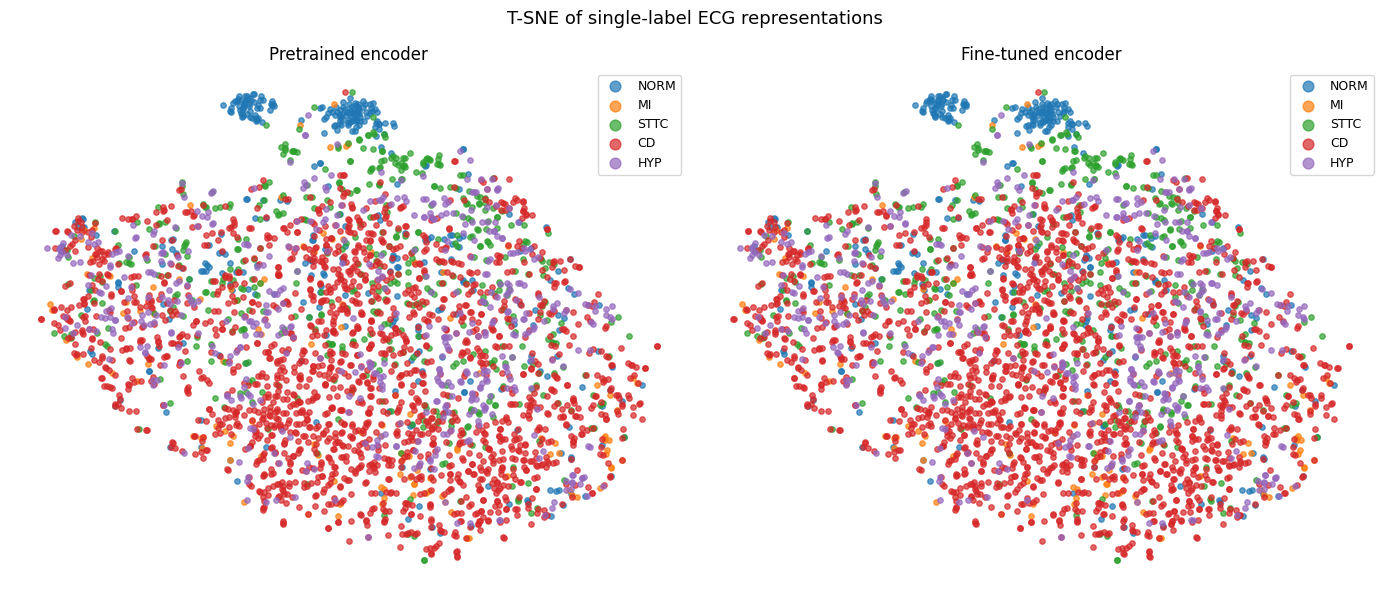

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# --- Filter to single-label samples from test + val sets ---
single_label_signals, single_label_classes = [], []
for dataset in [testset, valset]:
    for sig, lbl in dataset:
        if lbl.sum().item() == 1:
            single_label_signals.append(sig)
            single_label_classes.append(lbl.argmax().item())

signals_tensor = torch.stack(single_label_signals)  # (N, 12, 1000)
classes_array  = np.array(single_label_classes)      # (N,)
print(f"Single-label samples: {len(signals_tensor)} / {len(testset) + len(valset)}")

# --- Embedding extractor: mean-pool all C×N tokens → (N, embed_dim) ---
@torch.no_grad()
def get_embeddings(enc, signals, batch_size=64):
    enc.eval()
    all_embs = []
    for i in range(0, len(signals), batch_size):
        batch = signals[i:i + batch_size].to(device)
        batch = prepare_signal_for_encoder(batch)
        patches = enc.tokenizer.patchify(batch)          # (bs, 8, 50, 50)
        with torch.amp.autocast("cuda", enabled=amp_enabled):
            z = enc.forward_all(patches)                 # (bs, C*N, D)
        all_embs.append(z.mean(dim=1).cpu().float())     # mean-pool -> (bs, D)
    return torch.cat(all_embs).numpy()                   # (N, D)

embs_pretrained = get_embeddings(encoder, signals_tensor)
embs_finetuned  = get_embeddings(ft_model.encoder, signals_tensor)
print("Embeddings shape:", embs_pretrained.shape)

# --- T-SNE projections ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
proj_pre = tsne.fit_transform(embs_pretrained)
proj_ft  = tsne.fit_transform(embs_finetuned)

# --- Side-by-side plot ---
CLASS_NAMES = ["NORM", "MI", "STTC", "CD", "HYP"]
colors = plt.cm.tab10(np.arange(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, proj, title in [
    (axes[0], proj_pre, "Pretrained encoder"),
    (axes[1], proj_ft,  "Fine-tuned encoder"),
]:
    for cls_idx, name in enumerate(CLASS_NAMES):
        mask = classes_array == cls_idx
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=[colors[cls_idx]], label=name, s=15, alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.legend(loc="best", markerscale=2, fontsize=9)
    ax.axis("off")

plt.suptitle("T-SNE of single-label ECG representations", fontsize=13)
plt.tight_layout()
plt.show()